# Reveal paths to one fixed river

Hold the terminal board fixed at **5s 6s 7s Kh Kd**, enumerate all 20 flop/turn/river reveal histories, and compare symmetry breaking, simple relational signatures, and sampled conditional showdown expectations. Every assertion in this notebook is also a small executable test of the experiment's assumptions.

In [1]:
from collections import Counter
from itertools import combinations
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'experiments' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cards import FULL_DECK, RANKS, SUITS, card_name, cards_in, hand_names, make_hand
from chance import ChanceState, canonical_chance_children, state_stabilizer
from hand_space import PRIVATE_HANDS, hand_label
from showdown import compare_hands


## 1. Enumerate the 20 histories

A history chooses three of the five cards for the unordered flop, then orders the two remaining cards as turn and river: $\binom{5}{3}2=20$.

In [2]:
terminal_names = ['5s', '6s', '7s', 'Kh', 'Kd']
terminal_board = make_hand(terminal_names)
terminal_cards = cards_in(terminal_board)

def label(cards):
    return ''.join(hand_names(cards))

histories = []
for flop_cards in combinations(terminal_cards, 3):
    flop = sum(flop_cards)
    remaining = [card for card in terminal_cards if not flop & card]
    for turn_card, river_card in (remaining, remaining[::-1]):
        histories.append((flop, turn_card, river_card))

assert len(histories) == 20
assert len(set(histories)) == 20
assert all(flop | turn | river == terminal_board for flop, turn, river in histories)
print(f'{len(histories)} distinct histories; common endpoint: {label(terminal_board)}')

20 distinct histories; common endpoint: KdKh5s6s7s


## 2. Symmetry and relational path structure

The relational signature is deliberately small and exact: descending rank multiplicities, descending four-suit counts (zeros retained), and occupancy of the ten straight windows from A2345 through TJQKA. The stabiliser uses the preserved reveal history, while child-orbit counts group legal next cards under that state's stabiliser.

In [3]:
STRAIGHT_WINDOWS = [
    frozenset((12, 0, 1, 2, 3)),  # A2345
    *(frozenset(range(start, start + 5)) for start in range(9)),
]

def relational_signature(board):
    indexes = [card.bit_length() - 1 for card in cards_in(board)]
    ranks = [index % 13 for index in indexes]
    suits = [index // 13 for index in indexes]
    rank_multiplicities = tuple(sorted(Counter(ranks).values(), reverse=True))
    suit_multiplicities = tuple(sorted((suits.count(suit) for suit in range(4)), reverse=True))
    present_ranks = set(ranks)
    straight_incidence = tuple(len(present_ranks & window) for window in STRAIGHT_WINDOWS)
    return rank_multiplicities, suit_multiplicities, straight_incidence

path_rows = []
for path_id, (flop, turn_card, river_card) in enumerate(histories, 1):
    turn = flop | turn_card
    flop_state = ChanceState(flop, reveals=(flop,))
    turn_state = ChanceState(turn, reveals=(flop, turn_card))
    river_state = ChanceState(terminal_board, reveals=(flop, turn_card, river_card))
    path_rows.append({
        'path': path_id, 'flop': label(flop), 'turn': card_name(turn_card),
        'river': card_name(river_card), '|G_F|': len(state_stabilizer(flop_state)),
        '|G_T|': len(state_stabilizer(turn_state)), '|G_R|': len(state_stabilizer(river_state)),
        'flop child orbits': len(canonical_chance_children(flop_state)),
        'turn child orbits': len(canonical_chance_children(turn_state)),
        'R_F': relational_signature(flop), 'R_T': relational_signature(turn),
        'R_R': relational_signature(terminal_board),
    })

paths = pd.DataFrame(path_rows)
assert paths['R_R'].nunique() == 1
paths[['path', 'flop', 'turn', 'river', '|G_F|', '|G_T|', '|G_R|',
       'flop child orbits', 'turn child orbits']]

,path,flop,turn,river,|G_F|,|G_T|,|G_R|,flop child orbits,turn child orbits
0,1,KdKh5s,6s,7s,2,2,2,37,36
1,2,KdKh5s,7s,6s,2,2,2,37,36
2,3,KdKh6s,5s,7s,2,2,2,37,36
3,4,KdKh6s,7s,5s,2,2,2,37,36
4,5,KdKh7s,5s,6s,2,2,2,37,36
5,6,KdKh7s,6s,5s,2,2,2,37,36
6,7,Kd5s6s,Kh,7s,2,1,1,36,48
7,8,Kd5s6s,7s,Kh,2,2,1,36,35
8,9,Kd5s7s,Kh,6s,2,1,1,36,48
9,10,Kd5s7s,6s,Kh,2,2,1,36,35


In [4]:
signature_table = paths[['path', 'flop', 'turn', 'R_F', 'R_T']].copy()
signature_table.head(10)

,path,flop,turn,R_F,R_T
0,1,KdKh5s,6s,"((2, 1), (1, 1, 1, 0), (1, 1, 1, 1, 1, 0, 0, 0...","((2, 1, 1), (2, 1, 1, 0), (1, 2, 2, 2, 2, 1, 0..."
1,2,KdKh5s,7s,"((2, 1), (1, 1, 1, 0), (1, 1, 1, 1, 1, 0, 0, 0...","((2, 1, 1), (2, 1, 1, 0), (1, 1, 2, 2, 2, 1, 1..."
2,3,KdKh6s,5s,"((2, 1), (1, 1, 1, 0), (0, 1, 1, 1, 1, 1, 0, 0...","((2, 1, 1), (2, 1, 1, 0), (1, 2, 2, 2, 2, 1, 0..."
3,4,KdKh6s,7s,"((2, 1), (1, 1, 1, 0), (0, 1, 1, 1, 1, 1, 0, 0...","((2, 1, 1), (2, 1, 1, 0), (0, 1, 2, 2, 2, 2, 1..."
4,5,KdKh7s,5s,"((2, 1), (1, 1, 1, 0), (0, 0, 1, 1, 1, 1, 1, 0...","((2, 1, 1), (2, 1, 1, 0), (1, 1, 2, 2, 2, 1, 1..."
5,6,KdKh7s,6s,"((2, 1), (1, 1, 1, 0), (0, 0, 1, 1, 1, 1, 1, 0...","((2, 1, 1), (2, 1, 1, 0), (0, 1, 2, 2, 2, 2, 1..."
6,7,Kd5s6s,Kh,"((1, 1, 1), (2, 1, 0, 0), (1, 2, 2, 2, 2, 1, 0...","((2, 1, 1), (2, 1, 1, 0), (1, 2, 2, 2, 2, 1, 0..."
7,8,Kd5s6s,7s,"((1, 1, 1), (2, 1, 0, 0), (1, 2, 2, 2, 2, 1, 0...","((1, 1, 1, 1), (3, 1, 0, 0), (1, 2, 3, 3, 3, 2..."
8,9,Kd5s7s,Kh,"((1, 1, 1), (2, 1, 0, 0), (1, 1, 2, 2, 2, 1, 1...","((2, 1, 1), (2, 1, 1, 0), (1, 1, 2, 2, 2, 1, 1..."
9,10,Kd5s7s,6s,"((1, 1, 1), (2, 1, 0, 0), (1, 1, 2, 2, 2, 1, 1...","((1, 1, 1, 1), (3, 1, 0, 0), (1, 2, 3, 3, 3, 2..."


## 3. Sampled conditional showdown paths

Select 12 reproducible, mutually compatible private-hand pairs from the 1,081 hands that avoid the terminal board. For each pair, $M_F$ averages row-player dominance over all unordered turn/river completions after the flop; $M_T$ averages over all legal rivers after the turn; and $D_B$ is terminal dominance. Thus values lie in $[-1,1]$.

These expectations condition on the public street and the two sampled private hands. They do **not** condition future cards on reaching the chosen terminal board—that would make every earlier expectation equal to $D_B$ and erase the phenomenon being measured.

In [5]:
compatible_hands = [hand for hand in PRIVATE_HANDS if not hand & terminal_board]
assert len(compatible_hands) == 1081

rng = random.Random(20260928)
sample_pairs = []
while len(sample_pairs) < 12:
    first, second = rng.sample(compatible_hands, 2)
    if not first & second and (first, second) not in sample_pairs:
        sample_pairs.append((first, second))

pair_table = pd.DataFrame([
    {'pair': index, 'first': hand_label(first), 'second': hand_label(second)}
    for index, (first, second) in enumerate(sample_pairs, 1)
])
pair_table

,pair,first,second
0,1,3dQh,3cTd
1,2,QcJh,6c9d
2,3,5h6h,8d2s
3,4,Jc9h,7d8h
4,5,3s9s,3cTd
5,6,7hTh,3c4d
6,7,2d3h,QdTs
7,8,KsAs,6c4h
8,9,4c7h,Jc6d
9,10,3d4d,3c9c


In [6]:
def terminal_dominance(first, second, board):
    return compare_hands(first, second, board) - 1

def conditional_dominance(public_board, first, second):
    missing = 5 - public_board.bit_count()
    available = cards_in(FULL_DECK ^ (public_board | first | second))
    total = 0
    count = 0
    for completion in combinations(available, missing):
        final_board = public_board | sum(completion)
        total += terminal_dominance(first, second, final_board)
        count += 1
    return total / count

# Cache by public board and pair because each flop occurs in two paths.
expectation_cache = {}
def expectation(public_board, first, second):
    key = (public_board, first, second)
    if key not in expectation_cache:
        expectation_cache[key] = conditional_dominance(public_board, first, second)
    return expectation_cache[key]

chance_rows = []
for path_id, (flop, turn_card, river_card) in enumerate(histories, 1):
    turn = flop | turn_card
    for pair_id, (first, second) in enumerate(sample_pairs, 1):
        m_flop = expectation(flop, first, second)
        m_turn = expectation(turn, first, second)
        d_river = terminal_dominance(first, second, terminal_board)
        chance_rows.append({
            'path': path_id, 'pair': pair_id, 'M_F': m_flop, 'M_T': m_turn,
            'D_B': d_river, 'Delta_T': m_turn - m_flop,
            'Delta_R': d_river - m_turn,
        })

chance = pd.DataFrame(chance_rows)
assert len(chance) == 20 * len(sample_pairs)
assert np.allclose(chance['D_B'] - chance['M_F'], chance['Delta_T'] + chance['Delta_R'])
chance.head(12)

,path,pair,M_F,M_T,D_B,Delta_T,Delta_R
0,1,1,0.723232,0.863636,1,0.140404,0.136364
1,1,2,0.540404,-0.727273,-1,-1.267677,-0.272727
2,1,3,0.684848,0.863636,1,0.178788,0.136364
3,1,4,0.479798,0.409091,-1,-0.070707,-1.409091
4,1,5,-0.593939,-0.454545,1,0.139394,1.454545
5,1,6,0.509091,0.409091,-1,-0.100000,-1.409091
6,1,7,-0.520202,-0.545455,-1,-0.025253,-0.454545
7,1,8,0.909091,1.000000,1,0.090909,0.000000
8,1,9,-0.487879,-0.500000,1,-0.012121,1.500000
9,1,10,-0.503030,-0.500000,1,0.003030,1.500000


## 4. Compare how much arrives on each street

Aggregate absolute innovation over the sampled pairs. This does not turn the signatures into a metric; it is a compact first look for path-dependent information release.

In [7]:
innovation = (
    chance.assign(abs_Delta_T=lambda frame: frame['Delta_T'].abs(),
                  abs_Delta_R=lambda frame: frame['Delta_R'].abs())
    .groupby('path', as_index=False)
    .agg(mean_abs_Delta_T=('abs_Delta_T', 'mean'),
         mean_abs_Delta_R=('abs_Delta_R', 'mean'),
         rms_Delta_T=('Delta_T', lambda values: np.sqrt(np.mean(values**2))),
         rms_Delta_R=('Delta_R', lambda values: np.sqrt(np.mean(values**2))))
)
summary = paths.merge(innovation, on='path')
summary[['path', 'flop', 'turn', 'river', '|G_F|', '|G_T|',
         'flop child orbits', 'turn child orbits',
         'mean_abs_Delta_T', 'mean_abs_Delta_R']].sort_values('mean_abs_Delta_T', ascending=False)

,path,flop,turn,river,|G_F|,|G_T|,flop child orbits,turn child orbits,mean_abs_Delta_T,mean_abs_Delta_R
13,14,Kh5s6s,7s,Kd,2,2,36,35,0.582449,0.289773
7,8,Kd5s6s,7s,Kh,2,2,36,35,0.575800,0.289773
15,16,Kh5s7s,6s,Kd,2,2,36,35,0.533796,0.289773
9,10,Kd5s7s,6s,Kh,2,2,36,35,0.519066,0.289773
17,18,Kh6s7s,5s,Kd,2,2,36,35,0.464689,0.289773
11,12,Kd6s7s,5s,Kh,2,2,36,35,0.449958,0.289773
1,2,KdKh5s,7s,6s,2,2,37,36,0.442845,0.689394
3,4,KdKh6s,7s,5s,2,2,37,36,0.427946,0.594697
5,6,KdKh7s,6s,5s,2,2,37,36,0.306902,0.594697
6,7,Kd5s6s,Kh,7s,2,1,36,48,0.290572,0.829545


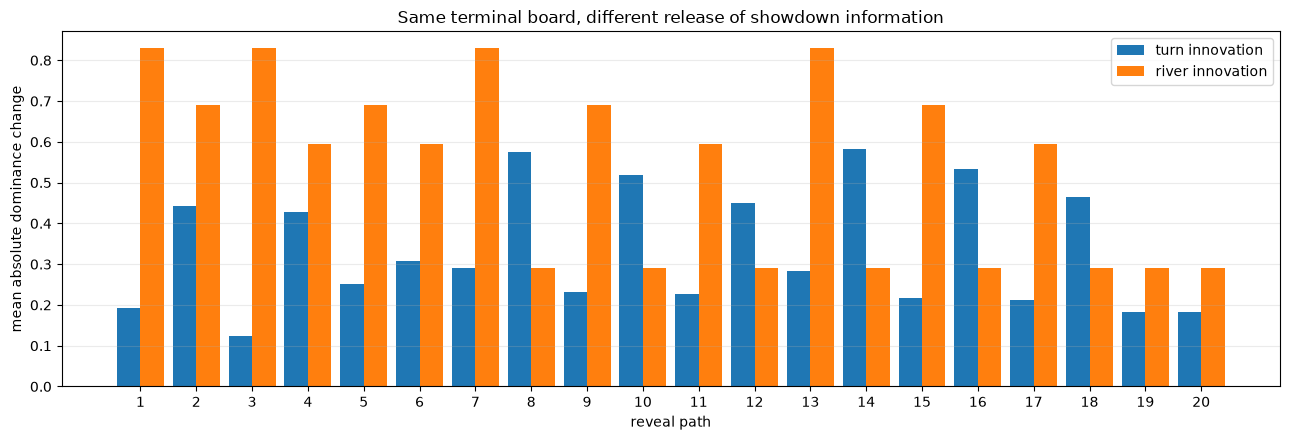

In [8]:
plot_data = summary.sort_values('path')
x = np.arange(len(plot_data))
width = 0.42
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(x - width / 2, plot_data['mean_abs_Delta_T'], width, label='turn innovation')
ax.bar(x + width / 2, plot_data['mean_abs_Delta_R'], width, label='river innovation')
ax.set(xticks=x, xticklabels=plot_data['path'], xlabel='reveal path',
       ylabel='mean absolute dominance change',
       title='Same terminal board, different release of showdown information')
ax.legend()
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## Checks and interpretation

The final cell verifies the central controls: all paths share one endpoint and one terminal result per sampled pair, while at least one structural profile and at least one innovation decomposition differ across paths.

In [9]:
assert chance.groupby('pair')['D_B'].nunique().eq(1).all()
assert summary[['|G_F|', '|G_T|', '|G_R|']].drop_duplicates().shape[0] > 1
assert summary[['mean_abs_Delta_T', 'mean_abs_Delta_R']].drop_duplicates().shape[0] > 1
assert np.isfinite(chance[['M_F', 'M_T', 'D_B', 'Delta_T', 'Delta_R']]).all().all()
print('All controls passed.')
print(f'Unique symmetry profiles: {summary[["|G_F|", "|G_T|", "|G_R|"]].drop_duplicates().shape[0]}')
print(f'Conditional expectations evaluated and cached: {len(expectation_cache)}')
print('The 20 paths have a common terminal operator but distinct structural and chance-information paths.')

All controls passed.
Unique symmetry profiles: 4
Conditional expectations evaluated and cached: 180
The 20 paths have a common terminal operator but distinct structural and chance-information paths.
